# Binary Classification Pipeline: Churn Prediction

- Phase 1: EDA & Audit
Data Quality: Document dtypes, ranges, and null-handling strategy for 20 features.



---


- Phase 2: Preprocessing




Splitting: Utilize pre-defined churn-80 and churn-20 sets.




---



- Phase 3: Architecture Experiments
Variant A: Shallow Wide (1 layer, 128 units, ReLU).

Variant B: Deep Narrow (4 layers, 32 units, ReLU).

Variant C: Activation Swap (Test tanh and LeakyReLU).

Logging: Provide training/validation loss curves and parameter counts for all.


---


- Phase 4: Optimization & Stability
Regularization: Implement Dropout and Batch Normalization.

Callbacks: Integrate Early Stopping and Learning Rate Reduction.

A/B Tests: Compare Weight Initialization and Optimizers (Adam, SGD, RMSprop).

---

- Phase 5: Imbalance Management
Baselines: Compare "Always No-Churn" accuracy against model performance.

Resampling: Implement Class Weights and SMOTE.

Thresholds: Plot Precision-Recall curve and justify an optimal decision threshold.

---

- Phase 6: Evaluation
Full Report: Per-class F1, ROC-AUC, and Confusion Matrix on the test set.

Calibration: Provide an ROC Curve overlay and a Reliability Diagram.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve,f1_score
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [5]:
train_df = pd.read_csv('Telecom_Churn/churn-bigml-80.csv')
test_df  = pd.read_csv('Telecom_Churn/churn-bigml-20.csv')

In [6]:
print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
train_df.head()

Train shape: (2666, 20)
Test  shape: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [7]:
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [8]:
train_df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [9]:
print(train_df.isnull().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [29]:
print(train_df.dtypes)

State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [30]:
cat_cols = ['International plan', 'Voice mail plan']

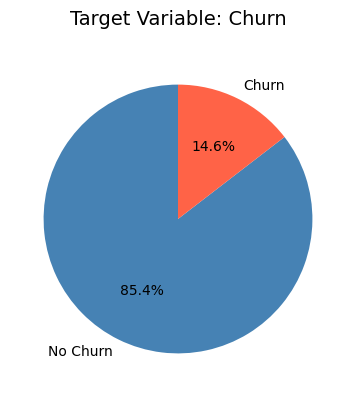

In [23]:
# Target distribution
plt.figure(figsize=(12, 4))

churn_counts = train_df['Churn'].value_counts()

plt.pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)

plt.suptitle('Target Variable: Churn', fontsize=14)
plt.tight_layout()
plt.show()


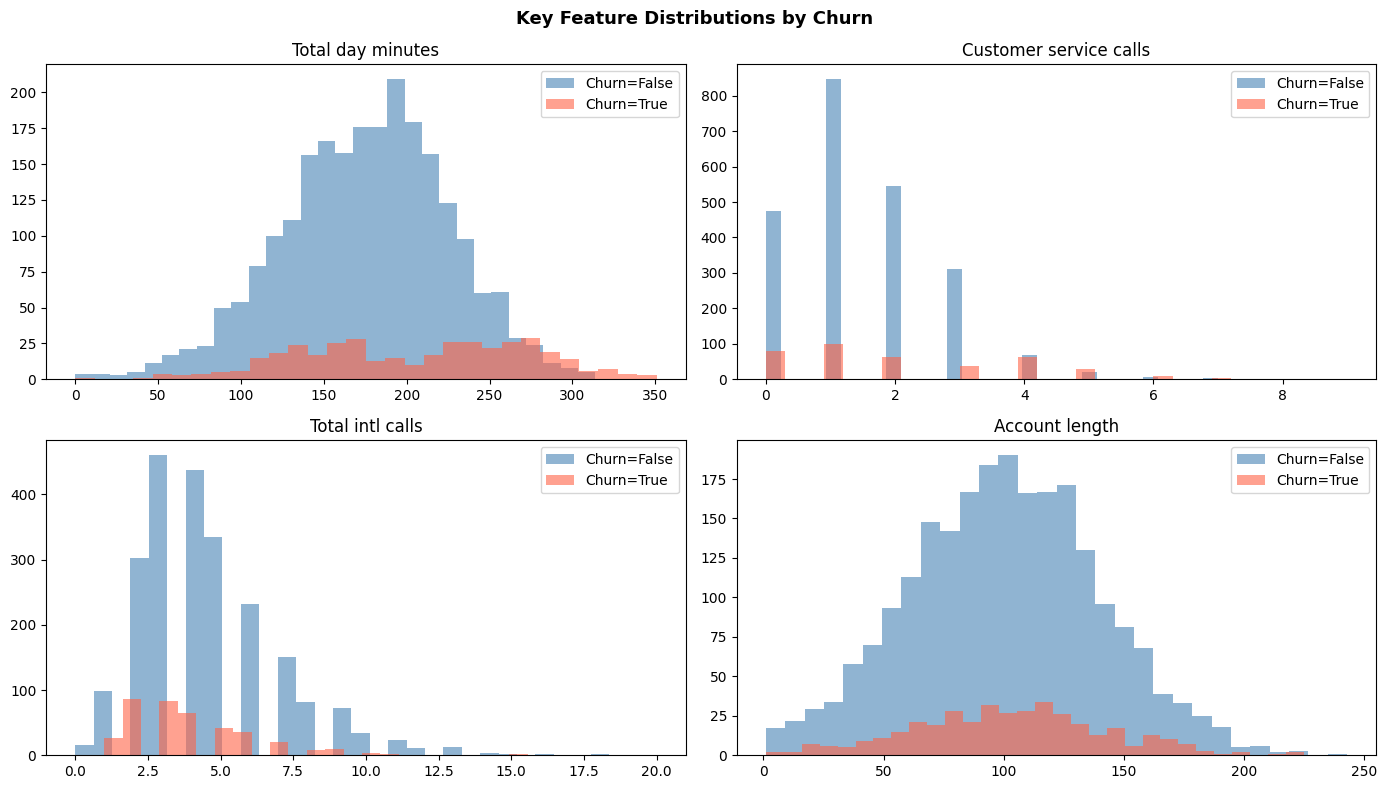

In [26]:
key_features = ['Total day minutes', 'Customer service calls',
                'Total intl calls', 'Account length']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color in [(False, 'steelblue'), (True, 'tomato')]:
        axes[i].hist(train_df[train_df['Churn'] == label][feat],
                     bins=30, alpha=0.6, color=color,
                     label=f'Churn={label}')
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('Key Feature Distributions by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Preprocessing

In [33]:
le = LabelEncoder()

for df in [train_df, test_df]:
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])   
    df['Churn'] = df['Churn'].astype(int)     
    df.drop(columns=['State', 'Area code'], inplace=True) #irrelevant

print('Features after encoding:', train_df.shape[1] - 1)
print(train_df.head(2))

Features after encoding: 17
   Account length  International plan  Voice mail plan  Number vmail messages  \
0             128                   0                1                     25   
1             107                   0                1                     26   

   Total day minutes  Total day calls  Total day charge  Total eve minutes  \
0              265.1              110             45.07              197.4   
1              161.6              123             27.47              195.5   

   Total eve calls  Total eve charge  Total night minutes  Total night calls  \
0               99             16.78                244.7                 91   
1              103             16.62                254.4                103   

   Total night charge  Total intl minutes  Total intl calls  \
0               11.01                10.0                 3   
1               11.45                13.7                 3   

   Total intl charge  Customer service calls  Churn  
0       

In [37]:
X_train = train_df.drop('Churn', axis=1).values
y_train = train_df['Churn'].values

X_test  = test_df.drop('Churn', axis=1).values
y_test  = test_df['Churn'].values

# Standardize
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('X_train:', X_train.shape)
print( 'X_test:', X_test.shape)

X_train: (2666, 17)
X_test: (667, 17)


In [42]:
# build model from spec
def build_model(layers_cfg, input_dim, activation='relu', optimizer='adam'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in layers_cfg:
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# train and return history
def train_model(model, X_tr, y_tr, epochs=50, batch=64, val_split=0.15, verbose=0):
    history = model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch,
                        validation_split=val_split, verbose=verbose)
    return history

# plot learning curves
def plot_learning_curves(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    colors = ['steelblue', 'tomato', 'seagreen', 'purple', 'orange']
    for i, (h, lbl) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        axes[0].plot(h.history['loss'],        color=c, label=f'{lbl} train')
        axes[0].plot(h.history['val_loss'],    color=c, linestyle='--', label=f'{lbl} val')
        axes[1].plot(h.history['accuracy'],    color=c, label=f'{lbl} train')
        axes[1].plot(h.history['val_accuracy'],color=c, linestyle='--', label=f'{lbl} val')
    for ax, title in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(title); ax.legend(fontsize=7); ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()



In [43]:
input_dim = X_train.shape[1]

# Variant A: Shallow Wide  (1 hidden layer, 128 units)
modelA = build_model([128], input_dim)
print('--- Variant A: Shallow Wide ---')
modelA.summary()
hA = train_model(modelA, X_train, y_train)

# Variant B: Deep Narrow  (4 hidden layers, 32 units each)
modelB = build_model([32, 32, 32, 32], input_dim)
print('--- Variant B: Deep Narrow ---')
modelB.summary()
hB = train_model(modelB, X_train, y_train)

# Variant C1: tanh activation
modelC1 = build_model([64, 64], input_dim, activation='tanh')
print('--- Variant C1: tanh ---')
modelC1.summary()
hC1 = train_model(modelC1, X_train, y_train)

# Variant C2: LeakyReLU (pass string directly in newer TF)
def build_leaky(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64), layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(64), layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

modelC2 = build_leaky(input_dim)
print('--- Variant C2: LeakyReLU ---')
modelC2.summary()
hC2 = train_model(modelC2, X_train, y_train)

--- Variant A: Shallow Wide ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 128)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

...

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 64)                  │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

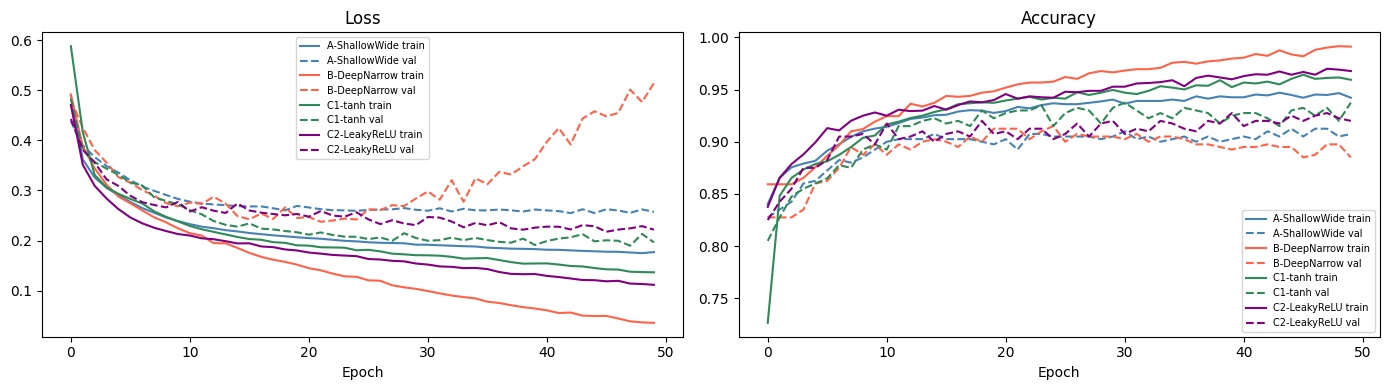


=== Parameter Counts ===
  A ShallowWide: 2,433 params
  B DeepNarrow: 3,777 params
  C1 tanh: 5,377 params
  C2 LeakyReLU: 5,377 params


In [44]:
# Loss & accuracy curves for all variants
plot_learning_curves([hA, hB, hC1, hC2],
          ['A-ShallowWide', 'B-DeepNarrow', 'C1-tanh', 'C2-LeakyReLU'])

# Parameter count summary
print('\n=== Parameter Counts ===')
for name, m in [('A ShallowWide', modelA), ('B DeepNarrow', modelB),
                ('C1 tanh',       modelC1), ('C2 LeakyReLU', modelC2)]:
    print(f'  {name}: {m.count_params():,} params')

In [48]:
def build_regularized(input_dim, optimizer='adam', init='glorot_uniform'):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu', kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu', kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu', kernel_initializer=init),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

# Optimizers
opt_results = {}
for opt_name in ['adam', 'sgd', 'rmsprop']:
    m = build_regularized(input_dim, optimizer=opt_name)
    h = m.fit(X_train, y_train, epochs=80, batch_size=64,
              validation_split=0.15, callbacks=callbacks, verbose=0)
    val_acc = max(h.history['val_accuracy'])
    opt_results[opt_name] = (h, val_acc)
    print(f'{opt_name:10s} → best val_acc: {val_acc:.4f}')


Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 36.
adam       → best val_acc: 0.9300

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
sgd        → best val_acc: 0.8450

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
rmsprop    → best val_acc: 0.9125


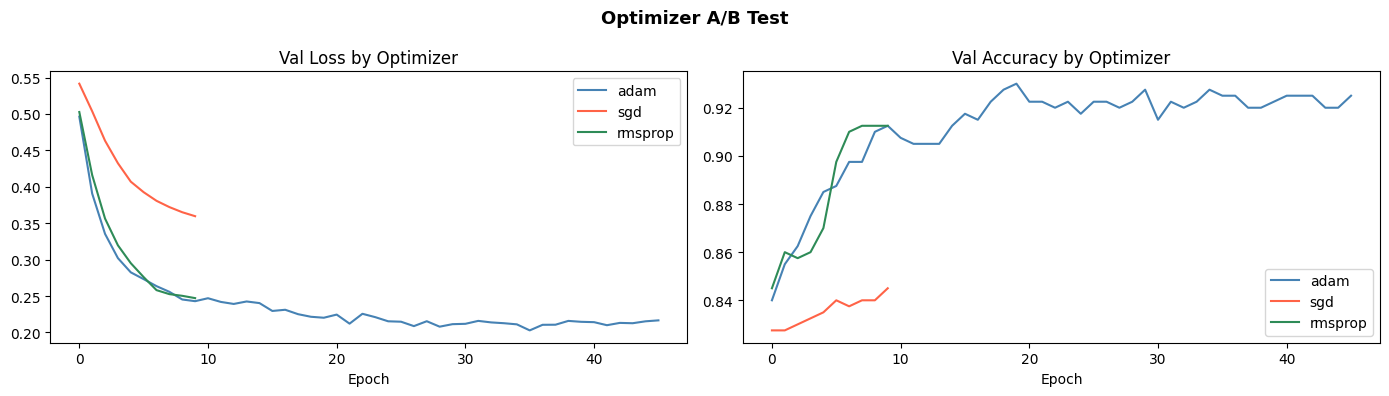

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {'adam': 'steelblue', 'sgd': 'tomato', 'rmsprop': 'seagreen'}
for opt_name, (h, _) in opt_results.items():
    c = colors[opt_name]
    axes[0].plot(h.history['val_loss'],     color=c, label=opt_name)
    axes[1].plot(h.history['val_accuracy'], color=c, label=opt_name)
axes[0].set_title('Val Loss by Optimizer');   axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('Val Accuracy by Optimizer'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.suptitle('Optimizer A/B Test', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [50]:
init_results = {}
for init_name in ['glorot_uniform', 'he_normal', 'random_normal']:
    m = build_regularized(input_dim, init=init_name)
    h = m.fit(X_train, y_train, epochs=80, batch_size=64,
              validation_split=0.15, callbacks=callbacks, verbose=0)
    val_acc = max(h.history['val_accuracy'])
    init_results[init_name] = (h, val_acc)
    print(f'{init_name:18s} → best val_acc: {val_acc:.4f}')


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
glorot_uniform     → best val_acc: 0.9100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
he_normal          → best val_acc: 0.8900

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
random_normal      → best val_acc: 0.8650


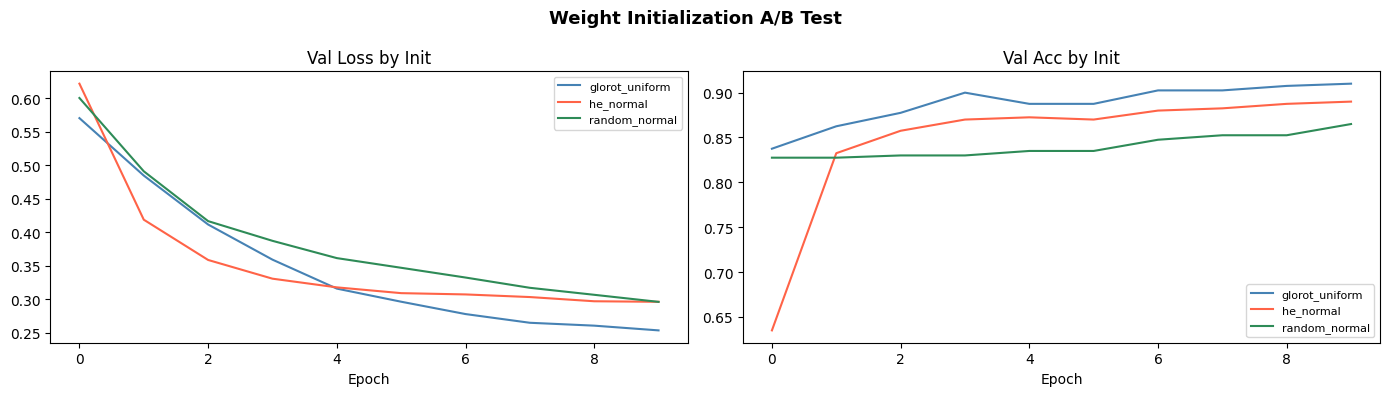

In [51]:
# initialization comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors2 = {'glorot_uniform': 'steelblue', 'he_normal': 'tomato', 'random_normal': 'seagreen'}
for name, (h, _) in init_results.items():
    c = colors2[name]
    axes[0].plot(h.history['val_loss'],     color=c, label=name)
    axes[1].plot(h.history['val_accuracy'], color=c, label=name)
axes[0].set_title('Val Loss by Init');   axes[0].legend(fontsize=8); axes[0].set_xlabel('Epoch')
axes[1].set_title('Val Acc by Init');    axes[1].legend(fontsize=8); axes[1].set_xlabel('Epoch')
plt.suptitle('Weight Initialization A/B Test', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Imbalance Management Baselines

In [55]:
baseline_acc = 1 - y_test.mean()
print(f'"Always No-Churn" baseline acc: {baseline_acc:.4f}')

"Always No-Churn" baseline acc: 0.8576


In [59]:
# Strategy 1: Class Weights
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print('Class weights:', class_weight_dict)

model_cw = build_regularized(input_dim)
h_cw = model_cw.fit(X_train, y_train, epochs=80, batch_size=64,
                    validation_split=0.15, class_weight=class_weight_dict,
                    callbacks=callbacks, verbose=0)

Class weights: {0: np.float64(0.5851624231782265), 1: np.float64(3.435567010309278)}

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.


In [60]:
# Strategy 2: SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Class 0: {(y_sm==0).sum()} | Class 1: {(y_sm==1).sum()}')

model_smote = build_regularized(input_dim)
h_smote = model_smote.fit(X_sm, y_sm, epochs=80, batch_size=64,
                          validation_split=0.15, callbacks=callbacks, verbose=0)

After SMOTE — Class 0: 2278 | Class 1: 2278

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


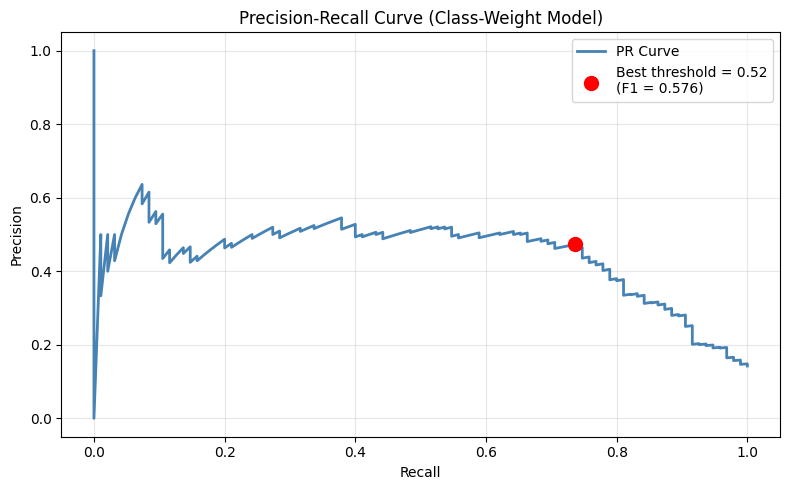


Optimal threshold: 0.524


In [63]:
y_prob_cw = model_cw.predict(X_test).flatten()

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_cw)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_idx  = np.argmax(f1_scores)
best_thr  = thresholds[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label='PR Curve')
plt.scatter(recall[best_idx], precision[best_idx], color='red', s=100, zorder=5,
            label=f'Best threshold = {best_thr:.2f}\n(F1 = {f1_scores[best_idx]:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Class-Weight Model)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nOptimal threshold: {best_thr:.3f}')

In [64]:
# Final model = Class-Weight model 
# Apply optimal threshold
y_prob_smote = model_smote.predict(X_test).flatten()

models_eval = {
    'Class Weights': (model_cw,    y_prob_cw,    best_thr),
    'SMOTE':         (model_smote, y_prob_smote, best_thr),
}

for name, (m, probs, thr) in models_eval.items():
    preds = (probs >= thr).astype(int)
    print(f'\n{'='*50}')
    print(f' Model: {name}  (threshold={thr:.2f})')
    print('='*50)
    print(classification_report(y_test, preds, target_names=['No Churn','Churn']))
    print(f'ROC-AUC: {roc_auc_score(y_test, probs):.4f}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Model: Class Weights  (threshold=0.52)
              precision    recall  f1-score   support

    No Churn       0.95      0.86      0.91       572
       Churn       0.47      0.74      0.58        95

    accuracy                           0.85       667
   macro avg       0.71      0.80      0.74       667
weighted avg       0.88      0.85      0.86       667

ROC-AUC: 0.8447

 Model: SMOTE  (threshold=0.52)
              precision    recall  f1-score   support

    No Churn       0.96      0.84      0.90       572
       Churn       0.45      0.79      0.57        95

    accuracy                           0.83       667
   macro avg       0.71      0.82      0.74       667
weighted avg       0.89      0.83      0.85       667

ROC-AUC: 0.8729


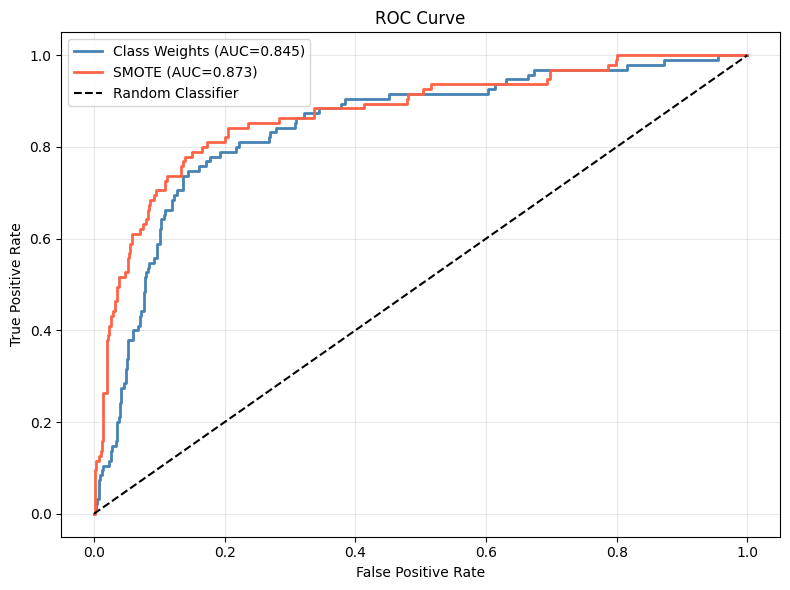

In [72]:
plt.figure(figsize=(8, 6))
colors_roc = ['steelblue', 'tomato']
for (name, (m, probs, thr)), c in zip(models_eval.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

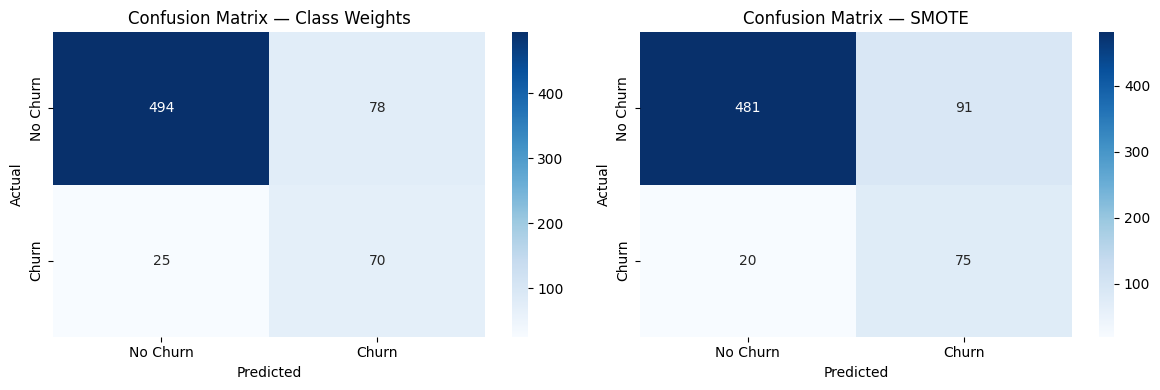

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (m, probs, thr)) in zip(axes, models_eval.items()):
    preds = (probs >= thr).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

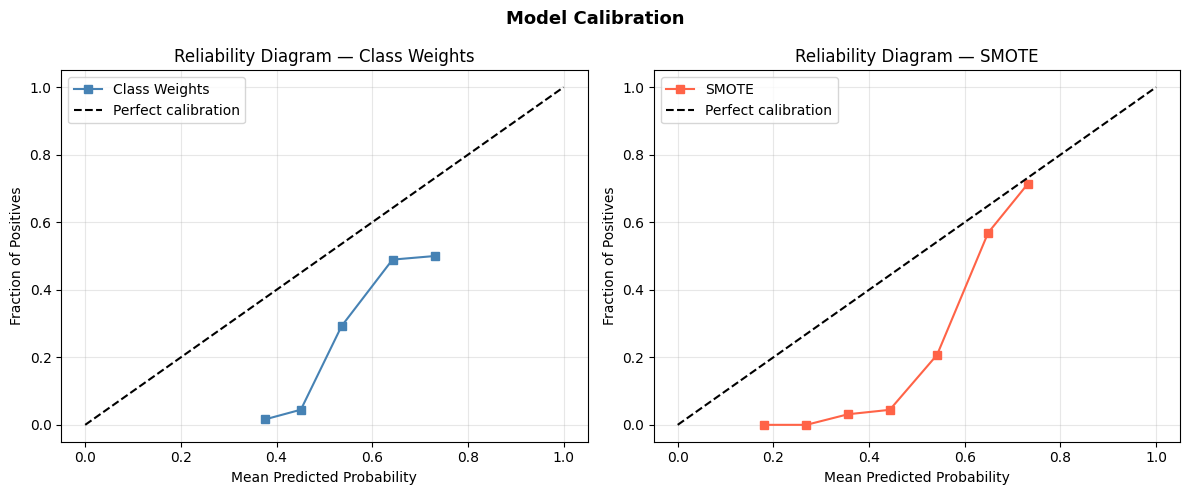

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, (m, probs, thr)), c in zip(axes, models_eval.items(), colors_roc):
    fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, fraction_pos, 's-', color=c, label=name)
    ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Reliability Diagram — {name}')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Model Calibration', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()